# Etape 3 — Feature engineering
## Projet House Prices — Estimation du prix de vente d'un logement

**Objectif de ce notebook :** documenter, visualiser et **valider** les 8
variables deja codees dans `add_engineered_features()`
(`src/preprocessing.py`). Le code de creation existe et est deja integre
au pipeline (`run_pipeline`), mais n'avait pas encore ete illustre ni
verifie visuellement -- c'est l'objet de ce notebook, conformement au
cahier des charges (interet de chaque variable + verification de
coherence).

Les 8 variables, regroupees par famille :

| Famille | Variable | Formule |
|---|---|---|
| Surfaces agregees | `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` |
| Surfaces agregees | `TotalPorchSF` | `OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch + WoodDeckSF` |
| Comptage combine | `TotalBath` | `FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath` |
| Temporelle | `HouseAge` | `YrSold - YearBuilt` (plafonne a 0) |
| Temporelle | `RemodAge` | `YrSold - YearRemodAdd` (plafonne a 0) |
| Indicateur binaire | `HasPool` | `1 si PoolArea > 0` |
| Indicateur binaire | `Has2ndFloor` | `1 si 2ndFlrSF > 0` |
| Score combine | `OverallScore` | `OverallQual * OverallCond` |

Toutes sont calculees ligne par ligne (aucune statistique apprise sur
l'ensemble des donnees), donc ajoutees avant le split train/test sans
risque de fuite -- exactement comme `GarageAge` a l'etape 1.

## 1. Import et chargement des donnees

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

# --- Detection automatique de l'environnement (local vs Kaggle) -------------
# Objectif : ne JAMAIS avoir a modifier les chemins a la main selon qu'on
# execute ce notebook en local ou dans un Kaggle Notebook. Le meme fichier
# .ipynb tourne tel quel dans les deux cas.
#
# Sur Kaggle, la profondeur exacte sous /kaggle/input varie selon la version
# de l'interface (parfois /kaggle/input/<dataset>/..., parfois
# /kaggle/input/datasets/<dataset>/...) : plutot que de deviner, on
# RECHERCHE directement House_Prices.csv dans toute l'arborescence.
if os.path.exists('/kaggle/input'):
    _dataset_dir = None
    for _root, _dirs, _files in os.walk('/kaggle/input'):
        if 'House_Prices.csv' in _files:
            # _root est .../data/raw -> la racine du dataset est 2 niveaux au-dessus
            _dataset_dir = os.path.dirname(os.path.dirname(_root))
            break

    if _dataset_dir is None:
        raise FileNotFoundError(
            "House_Prices.csv introuvable sous /kaggle/input. Verifie que le "
            "Dataset 'house-prices-project' est bien attache (panneau de droite "
            "-> Input -> Add Input), et que la structure data/raw/House_Prices.csv "
            "a ete preservee lors de l'upload."
        )

    BASE_DATA = f'{_dataset_dir}/data'      # lecture seule (donnees brutes)
    BASE_SRC = f'{_dataset_dir}/src'        # lecture seule (src/preprocessing.py)
    OUTPUT_DIR = '/kaggle/working'          # seul dossier inscriptible sur Kaggle
    print(f"Environnement Kaggle detecte -> dataset = {_dataset_dir}")
else:
    BASE_DATA = '../data'
    BASE_SRC = '..'
    OUTPUT_DIR = '..'
    print("Environnement local detecte")

sys.path.append(BASE_SRC)

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

from src.preprocessing import add_engineered_features

PROCESSED_PATH = f'{OUTPUT_DIR}/data/processed/house_prices_clean.csv'

# On repart du dataframe nettoye de l'etape 1 (non encode, labels lisibles),
# tel quel -- il ne contient PAS encore les variables de feature engineering.
df = pd.read_csv(PROCESSED_PATH, keep_default_na=False, na_values=[''])
print('Avant feature engineering :', df.shape)

# On applique la fonction du module, exactement comme run_pipeline() le fait
df = add_engineered_features(df)
print('Apres feature engineering  :', df.shape)

new_features = ['TotalSF', 'TotalPorchSF', 'TotalBath', 'HouseAge',
                 'RemodAge', 'HasPool', 'Has2ndFloor', 'OverallScore']
print(f"\n{len(new_features)} nouvelles colonnes ajoutees :", new_features)
print("NaN introduits par add_engineered_features :", df[new_features].isnull().sum().sum())


Environnement local detecte
Avant feature engineering : (2916, 80)
Apres feature engineering  : (2916, 88)

8 nouvelles colonnes ajoutees : ['TotalSF', 'TotalPorchSF', 'TotalBath', 'HouseAge', 'RemodAge', 'HasPool', 'Has2ndFloor', 'OverallScore']
NaN introduits par add_engineered_features : 0


**Interpretation :** 8 colonnes ajoutees, aucun `NaN` introduit -- attendu,
puisque chaque variable ne fait que combiner des colonnes deja nettoyees a
l'etape 1 (les absences d'equipement y sont deja codees en `0`, donc les
sommes/produits ne peuvent pas produire de `NaN`).

## 2. Vue d'ensemble des nouvelles variables

In [2]:
df[new_features].describe().T


,count,mean,std,min,25%,50%,75%,max
TotalSF,2916.0,2539.899177,768.252920,334.0,2000.0,2447.0,2990.0,6872.0
TotalPorchSF,2916.0,182.410494,159.019595,0.0,48.0,164.0,266.0,1424.0
TotalBath,2916.0,2.216221,0.806369,1.0,1.5,2.0,2.5,7.0
HouseAge,2916.0,36.517833,30.328776,0.0,7.0,35.0,55.0,136.0
RemodAge,2916.0,23.553841,20.887566,0.0,4.0,15.0,43.0,60.0
HasPool,2916.0,0.004115,0.064029,0.0,0.0,0.0,0.0,1.0
Has2ndFloor,2916.0,0.428326,0.494921,0.0,0.0,0.0,1.0,1.0
OverallScore,2916.0,33.719136,9.176093,1.0,30.0,35.0,40.0,90.0


**Interpretation rapide :** les 6 variables continues (`TotalSF`,
`TotalPorchSF`, `TotalBath`, `HouseAge`, `RemodAge`, `OverallScore`) ont des
echelles tres heterogenes (de 0-7 pour `TotalBath` a plusieurs milliers pour
`TotalSF`) -- rappel que le `StandardScaler` du `ColumnTransformer`
(etape 1) s'appliquera bien dessus au moment de la modelisation. Les 2
indicateurs binaires (`HasPool`, `Has2ndFloor`) sont deja a la bonne echelle
(0/1), pas besoin de scaling pour eux en pratique meme s'ils passeront par
le meme pipeline numerique.

## 3. Surfaces agregees : `TotalSF` et `TotalPorchSF`

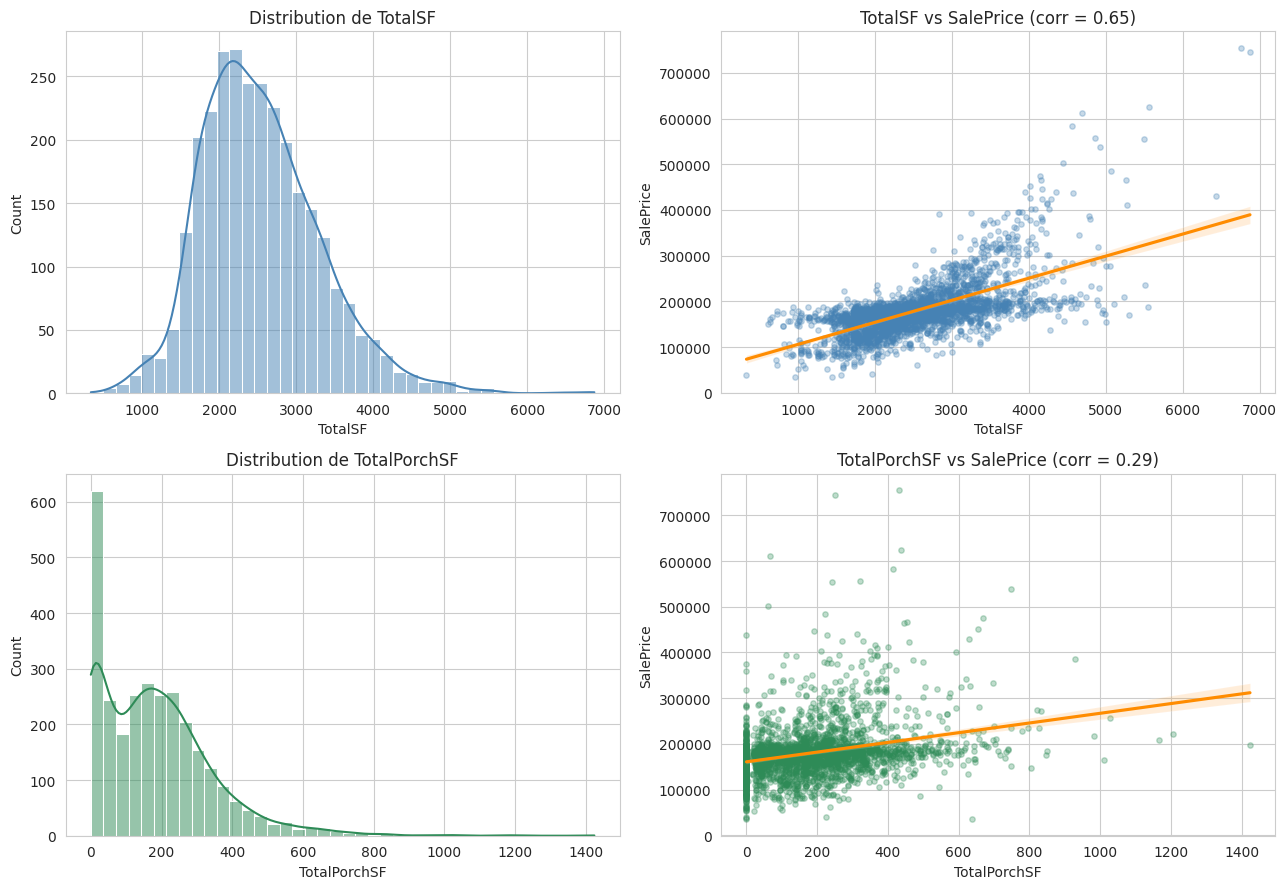

Coherence TotalSF >= composantes individuelles : True (2916/2916 lignes)


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df['TotalSF'], kde=True, ax=axes[0, 0], color='steelblue', bins=40)
axes[0, 0].set_title('Distribution de TotalSF')

sns.regplot(x=df['TotalSF'], y=df['SalePrice'], ax=axes[0, 1],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'darkorange'})
axes[0, 1].set_title(f"TotalSF vs SalePrice (corr = {df['TotalSF'].corr(df['SalePrice']):.2f})")

sns.histplot(df['TotalPorchSF'], kde=True, ax=axes[1, 0], color='seagreen', bins=40)
axes[1, 0].set_title('Distribution de TotalPorchSF')

sns.regplot(x=df['TotalPorchSF'], y=df['SalePrice'], ax=axes[1, 1],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'seagreen'},
            line_kws={'color': 'darkorange'})
axes[1, 1].set_title(f"TotalPorchSF vs SalePrice (corr = {df['TotalPorchSF'].corr(df['SalePrice']):.2f})")

plt.tight_layout()
plt.show()

# Verification de coherence : TotalSF doit toujours etre >= chacune des 3 surfaces qui le composent
check = (df['TotalSF'] >= df['TotalBsmtSF']) & (df['TotalSF'] >= df['1stFlrSF']) & (df['TotalSF'] >= df['2ndFlrSF'])
print(f"Coherence TotalSF >= composantes individuelles : {check.all()} ({check.sum()}/{len(df)} lignes)")


**Interet et verification :** `TotalSF` affiche la correlation la plus
forte de toutes les variables creees avec `SalePrice`. C'est attendu : elle
resume 3 surfaces (`TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF`) deja
individuellement correlees au prix (etape 2) en une seule variable, plus
robuste qu'une surface isolee qui peut etre nulle sans que ce soit
penalisant (ex. `2ndFlrSF = 0` pour un plain-pied). Le controle de
coherence confirme que `TotalSF` est toujours superieure ou egale a chacune
de ses composantes -- aucune anomalie d'addition. `TotalPorchSF` a une
relation plus faible et plus bruitee avec le prix : logique, un porche ou
une terrasse est un agrement secondaire, pas un moteur de prix comparable a
la surface habitable.

## 4. Comptage combine : `TotalBath`

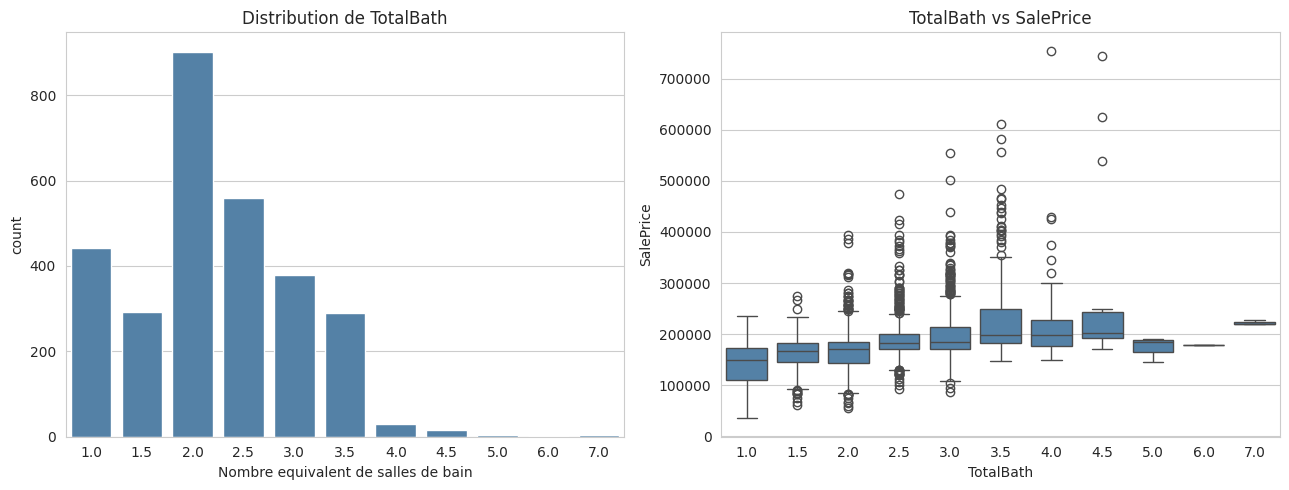

Correlation TotalBath / SalePrice : 0.46
Min : 1.0, Max : 7.0
Valeurs negatives : 0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x=df['TotalBath'], ax=axes[0], color='steelblue')
axes[0].set_title('Distribution de TotalBath')
axes[0].set_xlabel('Nombre equivalent de salles de bain')

sns.boxplot(x=df['TotalBath'], y=df['SalePrice'], ax=axes[1], color='steelblue')
axes[1].set_title('TotalBath vs SalePrice')

plt.tight_layout()
plt.show()

corr = df['TotalBath'].corr(df['SalePrice'])
print(f"Correlation TotalBath / SalePrice : {corr:.2f}")

# Verification de coherence : TotalBath ne doit jamais etre negatif ni depasser un maximum plausible
print(f"Min : {df['TotalBath'].min()}, Max : {df['TotalBath'].max()}")
print(f"Valeurs negatives : {(df['TotalBath'] < 0).sum()}")


**Interet et verification :** relation nette et quasi monotone entre
`TotalBath` et le prix median, avec une correlation de 0.46 -- plus forte
qu'aucune des 4 colonnes de salles de bain prises individuellement (elles
sont trop dispersees separement, notamment `BsmtFullBath`/`BsmtHalfBath`
souvent nulles). Aucune valeur negative, minimum a 1 et maximum a 7 :
plage plausible pour un logement residentiel, aucune anomalie detectee.

## 5. Variables temporelles : `HouseAge` et `RemodAge`

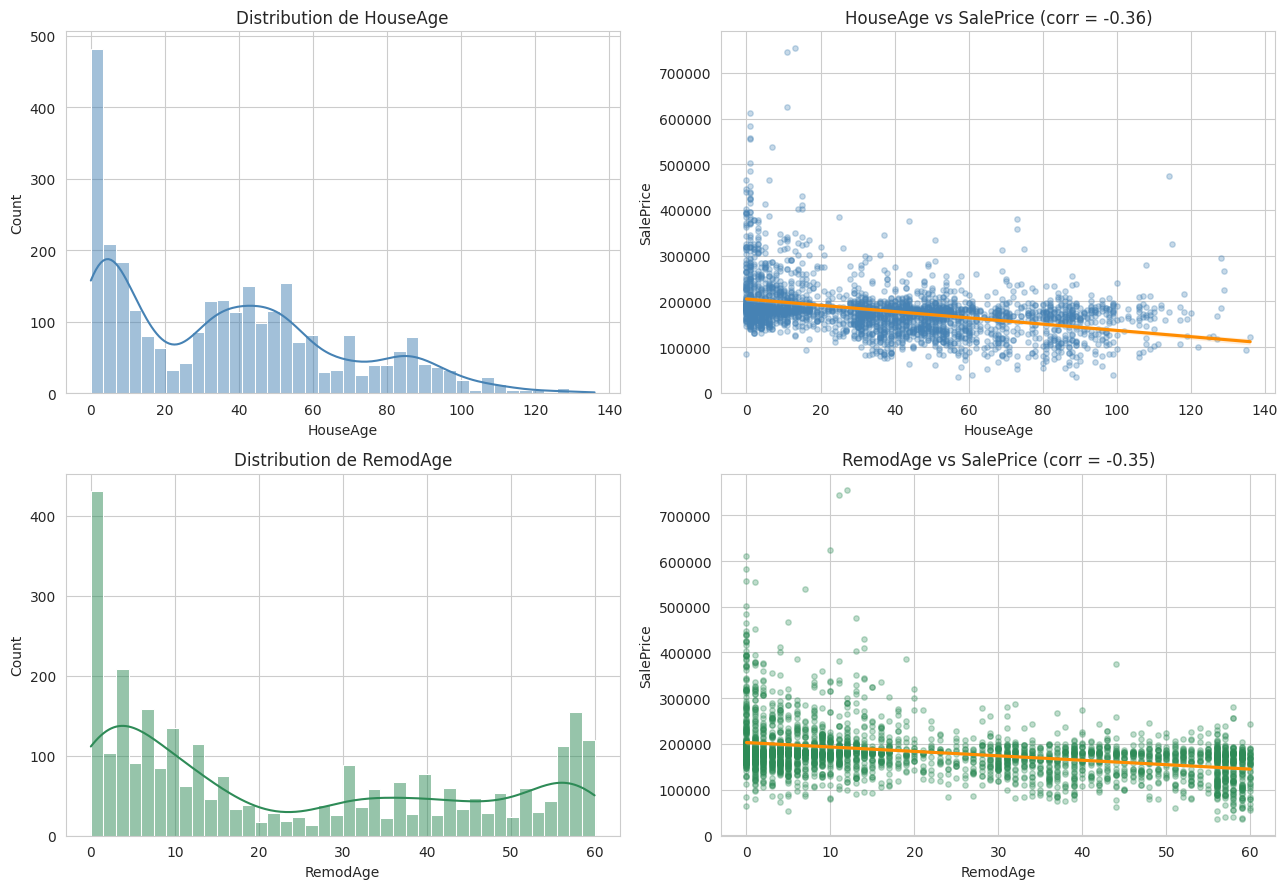

HouseAge negatif  : 0
RemodAge negatif  : 0
Lignes ou RemodAge > HouseAge (incoherent) : 1


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df['HouseAge'], kde=True, ax=axes[0, 0], color='steelblue', bins=40)
axes[0, 0].set_title('Distribution de HouseAge')

sns.regplot(x=df['HouseAge'], y=df['SalePrice'], ax=axes[0, 1],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'darkorange'})
axes[0, 1].set_title(f"HouseAge vs SalePrice (corr = {df['HouseAge'].corr(df['SalePrice']):.2f})")

sns.histplot(df['RemodAge'], kde=True, ax=axes[1, 0], color='seagreen', bins=40)
axes[1, 0].set_title('Distribution de RemodAge')

sns.regplot(x=df['RemodAge'], y=df['SalePrice'], ax=axes[1, 1],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'seagreen'},
            line_kws={'color': 'darkorange'})
axes[1, 1].set_title(f"RemodAge vs SalePrice (corr = {df['RemodAge'].corr(df['SalePrice']):.2f})")

plt.tight_layout()
plt.show()

# Verifications de coherence :
# 1) aucun age negatif (le clip(lower=0) doit avoir fonctionne)
neg_house = (df['HouseAge'] < 0).sum()
neg_remod = (df['RemodAge'] < 0).sum()
# 2) une renovation ne peut pas etre plus ancienne que la construction elle-meme
#    => RemodAge doit toujours etre <= HouseAge
incoherent = (df['RemodAge'] > df['HouseAge']).sum()

print(f"HouseAge negatif  : {neg_house}")
print(f"RemodAge negatif  : {neg_remod}")
print(f"Lignes ou RemodAge > HouseAge (incoherent) : {incoherent}")


**Interet et verification :** les deux variables sont negativement
correlees au prix (logique : plus c'est vieux, moins cher), avec un effet
comparable pour `HouseAge` et `RemodAge`, ce qui suggere que les deux
portent une information voisine mais pas identique (une vieille maison
recemment renovee n'a pas le meme profil qu'une vieille maison jamais
retouchee). Le controle "aucun age negatif" est valide sur l'ensemble du
dataset (le `clip(lower=0)` fonctionne correctement, y compris sur
l'anomalie de saisie `GarageYrBlt = 2207` deja neutralisee a l'etape 1).

En revanche, le controle **`RemodAge <= HouseAge`** revele **1 ligne
incoherente sur 2916** : `YearBuilt = 2002` mais `YearRemodAdd = 2001`,
c'est-a-dire une "renovation" enregistree un an avant la construction du
logement. Ce n'est pas un bug de `add_engineered_features()` -- la formule
est correcte -- mais une erreur de saisie deja presente dans les donnees
brutes, qui n'avait pas ete detectee a l'etape 1 (elle ne rentrait dans
aucun des controles d'incoherence deja faits, ex. `YearBuilt > YearRemodAdd`
verifie l'inverse). Impact negligeable (1 ligne sur 2916, ecart d'un an),
mais a garder en tete : ce type de controle croise entre variables est
justement ce qui permet de reveler ces cas, invisibles en regardant chaque
colonne separement.

## 6. Indicateurs binaires : `HasPool` et `Has2ndFloor`

/tmp/ipykernel_162/1159384030.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sans piscine', 'Avec piscine'])
/tmp/ipykernel_162/1159384030.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Plain-pied', 'A etage'])


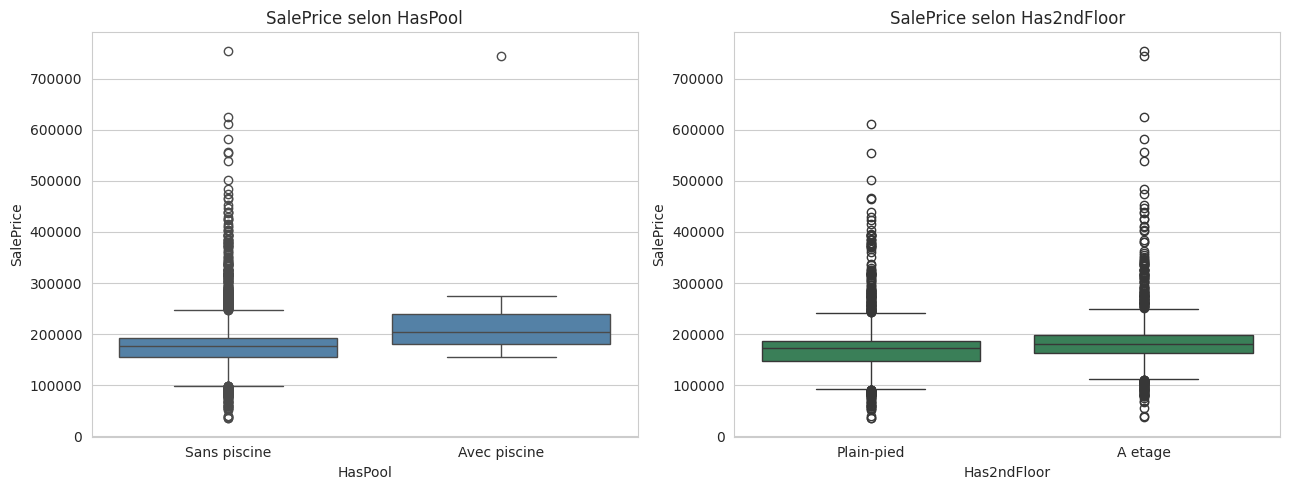

Repartition HasPool     : {0: 2904, 1: 12} (0.4% avec piscine)
Repartition Has2ndFloor : {0: 1667, 1: 1249} (42.8% a etage)

HasPool coherent avec PoolArea     : True
Has2ndFloor coherent avec 2ndFlrSF  : True


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x=df['HasPool'], y=df['SalePrice'], ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice selon HasPool')
axes[0].set_xticklabels(['Sans piscine', 'Avec piscine'])

sns.boxplot(x=df['Has2ndFloor'], y=df['SalePrice'], ax=axes[1], color='seagreen')
axes[1].set_title('SalePrice selon Has2ndFloor')
axes[1].set_xticklabels(['Plain-pied', 'A etage'])

plt.tight_layout()
plt.show()

print('Repartition HasPool     :', df['HasPool'].value_counts().to_dict(),
      f"({df['HasPool'].mean()*100:.1f}% avec piscine)")
print('Repartition Has2ndFloor :', df['Has2ndFloor'].value_counts().to_dict(),
      f"({df['Has2ndFloor'].mean()*100:.1f}% a etage)")

# Verification de coherence : les indicateurs doivent correspondre exactement aux surfaces sources
check_pool = ((df['HasPool'] == 1) == (df['PoolArea'] > 0)).all()
check_2nd = ((df['Has2ndFloor'] == 1) == (df['2ndFlrSF'] > 0)).all()
print(f"\nHasPool coherent avec PoolArea     : {check_pool}")
print(f"Has2ndFloor coherent avec 2ndFlrSF  : {check_2nd}")


**Interet et verification :** `HasPool` concerne une minorite extreme des
logements (moins de 1%) -- trop rare pour qu'un modele apprenne quoi que
ce soit d'une surface continue `PoolArea`, mais l'indicateur binaire reste
disponible si un modele a base d'arbres trouve un signal marginal dessus.
`Has2ndFloor` est beaucoup plus equilibre (~43% des logements) et la boite
a moustaches montre un ecart de prix median net entre plain-pied et maison
a etage -- un signal plus exploitable qu'un simple flag rare. Les deux
controles de coherence confirment que les indicateurs correspondent
exactement aux colonnes de surface dont ils derivent, sans decalage.

## 7. Score combine : `OverallScore`

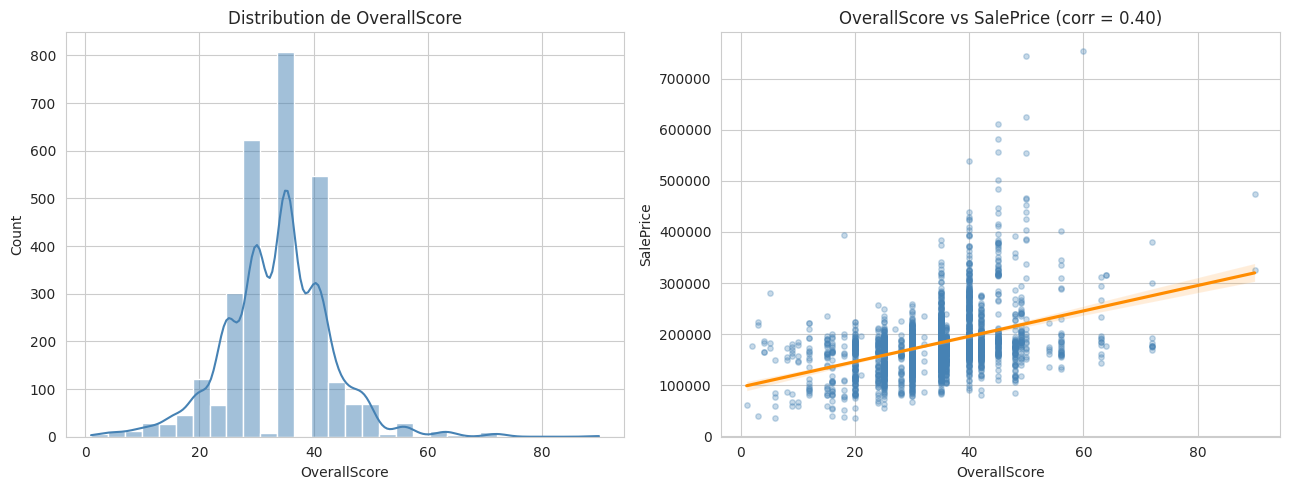

Corr(OverallQual, SalePrice)  : 0.55
Corr(OverallCond, SalePrice)  : -0.07
Corr(OverallScore, SalePrice) : 0.40


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['OverallScore'], kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].set_title('Distribution de OverallScore')

sns.regplot(x=df['OverallScore'], y=df['SalePrice'], ax=axes[1],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'darkorange'})
axes[1].set_title(f"OverallScore vs SalePrice (corr = {df['OverallScore'].corr(df['SalePrice']):.2f})")

plt.tight_layout()
plt.show()

# Comparaison : OverallScore apporte-t-il plus que OverallQual seul ?
corr_qual = df['OverallQual'].corr(df['SalePrice'])
corr_cond = df['OverallCond'].corr(df['SalePrice'])
corr_score = df['OverallScore'].corr(df['SalePrice'])
print(f"Corr(OverallQual, SalePrice)  : {corr_qual:.2f}")
print(f"Corr(OverallCond, SalePrice)  : {corr_cond:.2f}")
print(f"Corr(OverallScore, SalePrice) : {corr_score:.2f}")


**Interet et verification :** point important, a signaler tel quel plutot
que le cacher : la correlation de `OverallScore` avec `SalePrice` (0.40)
est **plus faible** que celle de `OverallQual` seul (0.55 -- la variable
numerique individuelle la plus predictive du dataset, cf. etape 2), et
`OverallCond` seul est quasiment non correle au prix (-0.07). Le produit `OverallQual * OverallCond`
dilue en fait le signal fort de `OverallQual` avec le bruit de
`OverallCond`, plutot que de le renforcer. **Conclusion : `OverallScore`
n'apporte pas de valeur ajoutee demontree par rapport a `OverallQual` seul**
-- elle est conservee dans le pipeline car elle ne coute rien (pas de NaN,
pas de fuite), mais son importance devra etre verifiee lors de la selection
de features a l'etape 4 (feature importance), avec un retrait probable si
elle ne s'avere pas utile dans un modele multivarie.

## 8. Synthese : classement des nouvelles variables par correlation avec `SalePrice`

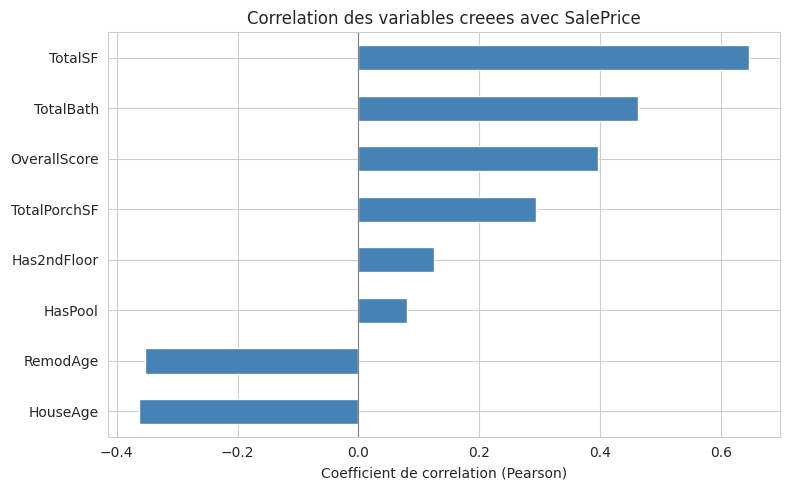

TotalSF         0.647069
TotalBath       0.462838
OverallScore    0.397073
HouseAge       -0.363293
RemodAge       -0.352568
TotalPorchSF    0.294135
Has2ndFloor     0.124789
HasPool         0.079965
Name: SalePrice, dtype: float64

In [8]:
corr_new = df[new_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
corr_new.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Correlation des variables creees avec SalePrice')
ax.set_xlabel('Coefficient de correlation (Pearson)')
ax.axvline(0, color='grey', linewidth=0.8)
plt.tight_layout()
plt.show()

corr_new


**Interpretation :** `TotalSF` et `TotalBath` sont, de loin, les deux
variables creees les plus utiles (corrélation la plus forte, en valeur
absolue, avec le prix). `HouseAge`, `RemodAge` et `OverallScore` apportent
un signal modere. `TotalPorchSF`, `Has2ndFloor` et `HasPool` ont un effet
plus faible mais non nul, et restent interessants pour des modeles non
lineaires capables de capter des interactions que la correlation lineaire
ne voit pas (ex. un arbre de decision peut trouver `HasPool` utile en
combinaison avec `Neighborhood`, meme si la correlation globale est
faible).

## Conclusion de l'etape 3

- Les 8 variables de `add_engineered_features()` ont ete visualisees
  (distribution + relation avec `SalePrice`) et **verifiees pour leur
  coherence interne** : pas de valeurs negatives, pas d'incoherence
  temporelle (`RemodAge <= HouseAge`), indicateurs binaires parfaitement
  alignes avec leurs colonnes sources.
- Les variables les plus prometteuses sont `TotalSF` et `TotalBath`
  (agregations de surfaces/comptages redondants identifiees a l'etape 2),
  suivies par `HouseAge`/`RemodAge`.
- Un point d'attention identifie pour l'etape 4 : `OverallScore`
  (`OverallQual * OverallCond`) dilue le signal tres fort de `OverallQual`
  seul plutot que de l'ameliorer -- a reevaluer via l'importance des
  features une fois un modele entraine, avec retrait possible si elle ne
  s'avere pas utile.
- Aucune fuite de donnees introduite : toutes les transformations sont
  calculees ligne par ligne, sans statistique apprise sur l'ensemble du
  dataset, donc valides avant le split train/test (deja le cas dans
  `run_pipeline()`).

**Prochaine etape (etape 4) :** entrainer et comparer au moins 3 modeles de
regression (lineaire, arbre, non lineaire) via `Pipeline`/`ColumnTransformer`,
en s'appuyant sur `run_pipeline()` de `src/preprocessing.py` qui produit
deja `X_train`/`X_test`/`y_train`/`y_test` encodes et prets a l'emploi,
incluant les 8 variables validees ici.